<a href="https://colab.research.google.com/github/annapurnajampana10/maskrcnn-floorplan-element-detection/blob/main/flooplan_detection_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mounting Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Extracting Dataset**

In [2]:
!unzip "/content/drive/MyDrive/cubicasa5k.zip" -d "/content/cubicasa_dataset"

Streaming output truncated to the last 5000 lines.
   creating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/4014/
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/4014/F1_scaled.png  
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/4014/F1_original.png  
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/4014/model.svg  
   creating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14296/
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14296/F1_scaled.png  
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14296/F1_original.png  
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14296/model.svg  
   creating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14295/
  inflating: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/14295/F2_scaled.png  
  inflating:

# **Installing Required Libraries**

In [3]:
!pip install opencv-python matplotlib lxml tqdm pycocotools beautifulsoup4

In [4]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [5]:
!pip install torchvision --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


# **Installing Detectron 2**

In [6]:
!pip install 'git+https://github.com/facebookresearch/detectron2.git'

  Cloning https://github.com/facebookresearch/detectron2.git to /tmp/pip-req-build-qekvp0ow
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/detectron2.git /tmp/pip-req-build-qekvp0ow
  Resolved https://github.com/facebookresearch/detectron2.git to commit fd27788985af0f4ca800bca563acdb700bb890e2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.0/55.0 kB 3.9 MB/s eta 0:00:00
  Created wheel for detectron2: filename=detectron2-0.6-cp312-cp312-linux_x86_64.whl size=6706493 sha256=c79b8d61f376173eca9a2b9517e8062989863e065823a36241797abce5cacc91
  Stored in di

# Parsing svg model and coco annotations

In [7]:
import os, json, re
from bs4 import BeautifulSoup
from PIL import Image

# --- Category map ---
categories = ["Wall", "Door", "Window", "Staircase"]
category_map = {label: idx + 1 for idx, label in enumerate(categories)}

# --- SVG loader ---
def extract_svg_root(svg_path):
    with open(svg_path, 'r', encoding='utf-8') as f:
        soup = BeautifulSoup(f, "xml")
    return soup.find("svg")

# --- Bounding box and segmentation parser ---
def parse_shape_bbox(shape):
    if shape is None:
        return None

    coords = []
    if shape.has_attr("points"):
        points_raw = shape["points"].strip().split()
        for p_str in points_raw:
            if not p_str:
                continue
            components = [comp for comp in p_str.split(',') if comp.strip()]
            if len(components) == 2:
                try:
                    coords.append((float(components[0]), float(components[1])))
                except ValueError:
                    pass
            else:
                pass

    elif shape.has_attr("d"):
        clean_d = re.sub(r"[MLHVCSQTAZmlhvcsqtaz]", " ", shape["d"])
        nums = re.findall(r"[-+]?\d*\.\d+|\d+", clean_d)
        coords = [(float(nums[i]), float(nums[i+1])) for i in range(0, len(nums)-1, 2)]

    else:
        return None

    if not coords:
        return None

    xs, ys = zip(*coords)
    bbox = [min(xs), min(ys), max(xs)-min(xs), max(ys)-min(ys)]

    # Flatten the coordinates for COCO segmentation format
    segmentation = [val for sublist in coords for val in sublist]
    return bbox, [segmentation]

# --- Separate parsers ---
def parse_walls(svg_root):
    walls = []
    for g in svg_root.find_all("g", class_=lambda c: c and "Wall" in c):
        shape = g.find(["polygon","polyline","path"])
        if shape:
            bbox_data = parse_shape_bbox(shape)
            if bbox_data:
                bbox, segmentation = bbox_data
                walls.append({"name":"Wall","bbox":bbox, "segmentation": segmentation})
    return walls

def parse_doors(svg_root):
    doors = []
    for g in svg_root.find_all("g", class_=lambda c: c and "Door" in c):
        shape = g.find(["polygon","polyline","path"])
        if shape:
            bbox_data = parse_shape_bbox(shape)
            if bbox_data:
                bbox, segmentation = bbox_data
                doors.append({"name":"Door","bbox":bbox, "segmentation": segmentation})
    return doors

def parse_windows(svg_root):
    windows = []
    for g in svg_root.find_all("g", class_=lambda c: c and "Window" in c):
        shape = g.find(["polygon","polyline","path"])
        if shape:
            bbox_data = parse_shape_bbox(shape)
            if bbox_data:
                bbox, segmentation = bbox_data
                windows.append({"name":"Window","bbox":bbox, "segmentation": segmentation})
    return windows

def parse_staircases(svg_root):
    stairs = []
    for g in svg_root.find_all("g", class_=lambda c: c and "Stairs" in c):
        shape = g.find(["polygon","polyline","path"])
        if shape:
            bbox_data = parse_shape_bbox(shape)
            if bbox_data:
                bbox, segmentation = bbox_data
                stairs.append({"name":"Staircase","bbox":bbox, "segmentation": segmentation})
    return stairs


# --- Unified parser ---
def parse_elements(svg_root):
    elements = []
    elements.extend(parse_walls(svg_root))
    elements.extend(parse_doors(svg_root))
    elements.extend(parse_windows(svg_root))
    elements.extend(parse_staircases(svg_root))
    return elements

# --- Annotation generator ---
def generate_annotations(elements, image_id, start_id=1):
    annotations = []
    ann_id = start_id
    for el in elements:
        category_id = category_map[el["name"]]
        area = el["bbox"][2] * el["bbox"][3]
        annotations.append({
            "id": ann_id,
            "image_id": image_id,
            "category_id": category_id,
            "bbox": el["bbox"],
            "area": area,
            "iscrowd": 0,
            "segmentation": el["segmentation"]
        })
        ann_id += 1
    return annotations

# --- Folder processor ---
def process_svg_folder(folder_path, output_json):
    images = []
    annotations = []
    image_id = 1000
    ann_id = 1

    for filename in os.listdir(folder_path):
        if not filename.endswith(".svg"):
            continue

        svg_path = os.path.join(folder_path, filename)
        svg_root = extract_svg_root(svg_path)
        elements = parse_elements(svg_root)

        images.append({
            "id": image_id,
            "file_name": filename,
            "width": 2048,
            "height": 2048
        })

        anns = generate_annotations(elements, image_id, start_id=ann_id)
        annotations.extend(anns)
        ann_id += len(anns)
        image_id += 1

    coco_data = {
        "images": images,
        "annotations": annotations,
        "categories": [{"id": cid, "name": name} for name, cid in category_map.items()]
    }

    with open(output_json, "w") as f:
        json.dump(coco_data, f, indent=2)
    print(f"✅ Saved {output_json} with {len(images)} images and {len(annotations)} annotations.")

In [8]:
# --- Split processor ---
base_dir = "/content/cubicasa_dataset/cubicasa5k"

def process_split(split_name, folder_paths, output_json):
    images, annotations = [], []
    image_id, ann_id = 1000, 1
    present_categories = set()

    category_lookup = {cid: name for name, cid in category_map.items()}

    for relative_path in folder_paths:
        svg_path = os.path.join(base_dir, relative_path, "model.svg")
        png_path = os.path.join(base_dir, relative_path, "F1_scaled.png")

        if not os.path.exists(svg_path):
            print(f" model.svg not found at {svg_path}")
            continue
        if not os.path.exists(png_path):
            print(f" F1_scaled.png not found at {png_path}")
            continue

        try:
            with Image.open(png_path) as img:
                width, height = img.size
        except Exception as e:
            print(f" Could not read image size for {png_path}: {e}")
            continue

        svg_root = extract_svg_root(svg_path)
        elements = parse_elements(svg_root)

        style = relative_path.split("/")[0]

        images.append({
            "id": image_id,
            "file_name": png_path,
            "style": style,
            "width": width,
            "height": height
        })

        anns = generate_annotations(elements, image_id, start_id=ann_id)
        annotations.extend(anns)
        ann_id += len(anns)
        image_id += 1

        for ann in anns:
            if ann["category_id"] in category_lookup:
                present_categories.add(category_lookup[ann["category_id"]])
            else:
                print(f" Category ID {ann['category_id']} not found in category_lookup.")

    categories_list = [{"id": cid, "name": name} for name, cid in category_map.items()]

    coco_data = {
        "info": {
            "description": f"Floorplan Dataset - {split_name} split",
            "version": "1.0",
            "year": 2023,
            "contributor": "Google Colab",
            "date_created": ""
        },
        "images": images,
        "annotations": annotations,
        "categories": categories_list
    }

    os.makedirs(os.path.dirname(output_json), exist_ok=True)
    with open(output_json, "w") as f:
        json.dump(coco_data, f, indent=2)
    print(f"✅ Saved {split_name} annotations to {output_json} with {len(images)} images and {len(annotations)} annotations.")

In [9]:
image_id = 1000
ann_id = 1
annotations = []

svg_path = "/content/cubicasa_dataset/cubicasa5k/high_quality_architectural/1000/model.svg"
svg_root = extract_svg_root(svg_path)
elements = parse_elements(svg_root)

anns = generate_annotations(elements, image_id, start_id=ann_id)
annotations.extend(anns)

# **Spliting annotations as train, test and validation sets**

In [10]:
import os

# --- loader for train/val/test split files ---
def load_split_list(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()
    # take the last part of each line, strip spaces, and remove leading slash
    return [line.strip().split()[-1].lstrip("/") for line in lines]

# --- Use the loader ---
train_folders = load_split_list(os.path.join(base_dir, "train.txt"))
val_folders   = load_split_list(os.path.join(base_dir, "val.txt"))
test_folders  = load_split_list(os.path.join(base_dir, "test.txt"))

# --- Process splits ---
process_split("train", train_folders, os.path.join(base_dir, "annotations/train.json"))
process_split("val",   val_folders,   os.path.join(base_dir, "annotations/val.json"))
process_split("test",  test_folders,  os.path.join(base_dir, "annotations/test.json"))

# --- Example check  ---
sample_folder = train_folders[0]
svg_path = os.path.join(base_dir, sample_folder, "model.svg")
print("Looking for:", svg_path)
print("Exists?", os.path.exists(svg_path))

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (90344064 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


✅ Saved train annotations to /content/cubicasa_dataset/cubicasa5k/annotations/train.json with 4200 images and 201506 annotations.
✅ Saved val annotations to /content/cubicasa_dataset/cubicasa5k/annotations/val.json with 400 images and 18477 annotations.
✅ Saved test annotations to /content/cubicasa_dataset/cubicasa5k/annotations/test.json with 400 images and 19521 annotations.
Looking for: /content/cubicasa_dataset/cubicasa5k/high_quality_architectural/6044/model.svg
Exists? True


# **Visualizing sample annotations**

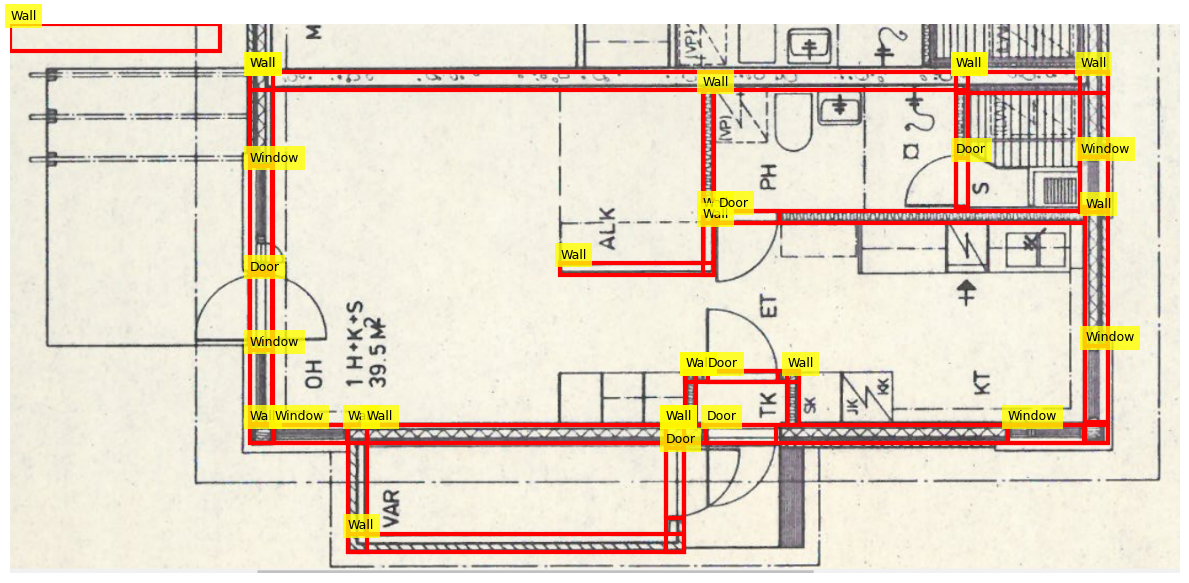

In [11]:
import json
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Load annotations
with open("/content/cubicasa_dataset/cubicasa5k/annotations/val.json") as f:
    coco = json.load(f)

# Build image and category lookup
image_lookup = {img["id"]: img for img in coco["images"]}
category_lookup = {cat["id"]: cat["name"] for cat in coco["categories"]}

# Visualize one image
def visualize_image(image_id, base_dir):
    img_info = image_lookup[image_id]
    img_path = os.path.join("/content/cubicasa_dataset/cubicasa5k", img_info["file_name"])

    if not os.path.exists(img_path):
        print(f" Image not found: {img_path}")
        return

    image = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(12, 10))
    ax.imshow(image)

    for ann in coco["annotations"]:
        if ann["image_id"] != image_id:
            continue

        x, y, w, h = ann["bbox"]
        label = category_lookup.get(ann["category_id"], "Unlabeled")

        # Thicker box lines
        edge_color = 'red' if label != "Unlabeled" else 'gray'
        rect = patches.Rectangle((x, y), w, h, linewidth=3, edgecolor=edge_color, facecolor='none')
        ax.add_patch(rect)

        #  Label background
        text_color = 'black' if label != "Unlabeled" else 'gray'
        bg_color = 'yellow' if label != "Unlabeled" else 'lightgray'
        ax.text(x, y - 5, label,
                fontsize=9,
                color=text_color,
                bbox=dict(facecolor=bg_color, alpha=0.8, edgecolor='none'))

    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example usage
if coco["images"]:
    first_image_id = coco["images"][0]["id"]
    visualize_image(first_image_id, "/content/cubicasa_dataset/cubicasa5k")
else:
    print("No images found in the annotations.")

# Registering COCO Datasets

In [12]:
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog

# It's crucial that 'categories' is defined before this cell.
# It is defined in cell 'enMlH04EstAz', which is executed before P0j5qR4x8puZ in the history.
# So 'categories' should be available.

# Define the datasets to be registered
datasets_info = [
    ("floorplan_train", "/content/cubicasa_dataset/cubicasa5k/annotations/train.json", "/content/cubicasa_dataset/cubicasa5k"),
    ("floorplan_val",   "/content/cubicasa_dataset/cubicasa5k/annotations/val.json",   "/content/cubicasa_dataset/cubicasa5k"),
    ("floorplan_test",  "/content/cubicasa_dataset/cubicasa5k/annotations/test.json",  "/content/cubicasa_dataset/cubicasa5k")
]

for name, json_file, image_root in datasets_info:
    if name in DatasetCatalog.list():
        print(f"Dataset '{name}' is already listed. Attempting to clean and re-register.")
        # Explicitly try to remove the 'json_file' attribute from metadata if it's there
        # This is a workaround for cases where DatasetCatalog.remove() doesn't fully clear it.
        if hasattr(MetadataCatalog.get(name), "json_file"):
            delattr(MetadataCatalog.get(name), "json_file")
            print(f"  Removed 'json_file' from MetadataCatalog for '{name}'.")
        DatasetCatalog.remove(name)
        print(f"  Dataset '{name}' removed from DatasetCatalog.")

    # Now, register the dataset
    register_coco_instances(name, {}, json_file, image_root)
    print(f"Dataset '{name}' registered successfully.")

    # Assign/update thing_classes and ensure json_file is correctly set in metadata
    MetadataCatalog.get(name).thing_classes = categories
    # No need to explicitly set json_file here again, as register_coco_instances has just set it,
    # and we just cleared any potential old conflicting value.
    MetadataCatalog.get(name).image_root = image_root # Explicitly set image_root in metadata
    print(f"Metadata for '{name}' updated with thing_classes: {MetadataCatalog.get(name).thing_classes}")
    print(f"Metadata for '{name}' json_file: {MetadataCatalog.get(name).json_file}")

print("All COCO datasets are prepared.")

Dataset 'floorplan_train' registered successfully.
Metadata for 'floorplan_train' updated with thing_classes: ['Wall', 'Door', 'Window', 'Staircase']
Metadata for 'floorplan_train' json_file: /content/cubicasa_dataset/cubicasa5k/annotations/train.json
Dataset 'floorplan_val' registered successfully.
Metadata for 'floorplan_val' updated with thing_classes: ['Wall', 'Door', 'Window', 'Staircase']
Metadata for 'floorplan_val' json_file: /content/cubicasa_dataset/cubicasa5k/annotations/val.json
Dataset 'floorplan_test' registered successfully.
Metadata for 'floorplan_test' updated with thing_classes: ['Wall', 'Door', 'Window', 'Staircase']
Metadata for 'floorplan_test' json_file: /content/cubicasa_dataset/cubicasa5k/annotations/test.json
All COCO datasets are prepared.


# **Visualizing sample from registered coco dataset**

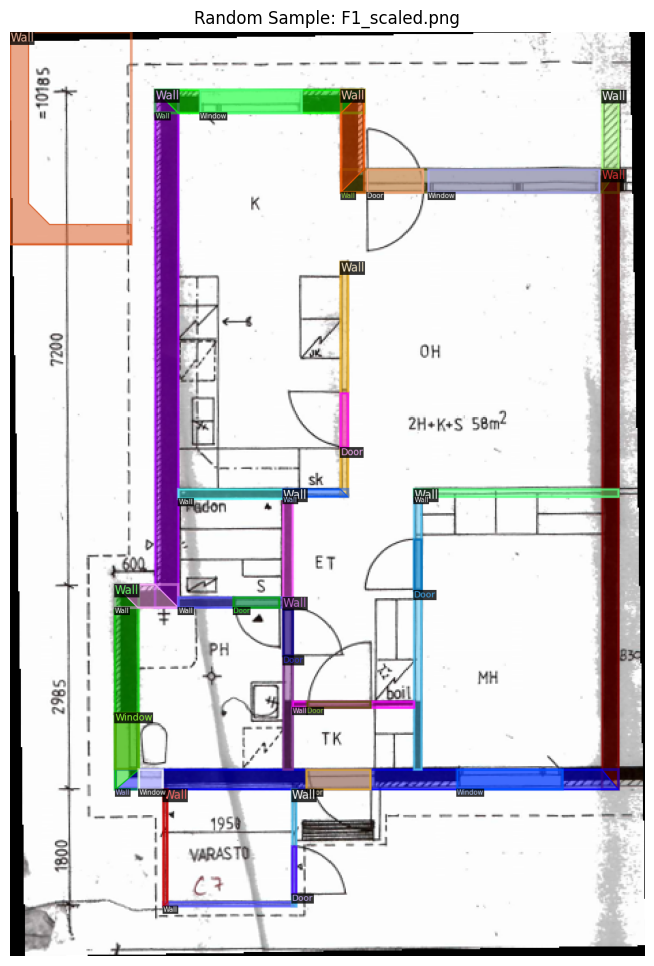

In [13]:
import os
import cv2
import random
import matplotlib.pyplot as plt
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog, Metadata # Import Metadata
from detectron2.data.datasets import load_coco_json # Import load_coco_json

# Choose your dataset annotation file
annotation_file = "/content/cubicasa_dataset/cubicasa5k/annotations/val.json"

# Load dataset dictionaries directly
try:
    dataset_dicts = load_coco_json(annotation_file, "/content/")
except FileNotFoundError:
    print(f"Error: Annotation file not found at {annotation_file}")
    dataset_dicts = [] # Set to empty list to prevent further errors

if dataset_dicts:
    # Create metadata manually
    # Ensure category_map is available globally from ZU6U7nelTH2c
    if 'category_map' not in globals():
        print("Error: category_map not found. Please run the data processing cell (ZU6U7nelTH2c) first.")
        metadata = Metadata() # Create empty metadata to prevent errors
    else:
        metadata = Metadata()
        # Add a dummy '__background__' class at index 0 to align with 1-indexed COCO categories
        metadata.thing_classes = ["__background__"] + list(category_map.keys()) # Set thing_classes from category_map
        # You might also want to set other metadata attributes like thing_colors if available
        # metadata.thing_colors = [...]


    # Pick a random sample
    sample = random.choice(dataset_dicts)

    # Construct the full image path from the file_name in the dataset dict
    img_path = sample["file_name"]


    # Load image safely
    img = cv2.imread(img_path)
    if img is None:
        print(f"⚠️ Image not found or unreadable: {img_path}")
    else:
        # Ensure image is in BGR format for Visualizer
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR) # Convert from RGB (Pillow default) to BGR (OpenCV default) if necessary, assuming image is read as RGB by default

        visualizer = Visualizer(img[:, :, ::-1], metadata=metadata, scale=1.0) # Pass manual metadata
        vis = visualizer.draw_dataset_dict(sample)

        plt.figure(figsize=(12, 12))
        plt.imshow(vis.get_image())
        plt.axis('off')
        plt.title(f"Random Sample: {os.path.basename(img_path)}")
        plt.show()
else:
    print("No dataset dictionaries loaded for visualization.")

## **Model Training (Mask R-CNN with detectron and pytorch)**

In [14]:
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

cfg = get_cfg()
# Use model_zoo to get the correct path for the config file
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.DATASETS.TRAIN = ("floorplan_train",)
cfg.DATASETS.TEST = ("floorplan_val",)
cfg.DATALOADER.NUM_WORKERS = 2

cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml")
cfg.SOLVER.IMS_PER_BATCH = 2
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 2000
cfg.SOLVER.CHECKPOINT_PERIOD = 100
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128
cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4

# Explicitly set mask format to polygon
cfg.INPUT.MASK_FORMAT = "polygon"

# Configure to use CPU
cfg.MODEL.DEVICE = 'cpu'

cfg.OUTPUT_DIR = "/content/drive/MyDrive/floorplan_detection_output"
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

trainer = DefaultTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

[01/17 04:29:20 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4317.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0117 04:29:51.873000 330 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[01/17 04:44:43 d2.utils.events]:  eta: 6:04:53  iter: 1519  total_loss: 1.798  loss_cls: 0.3719  loss_box_reg: 0.5383  loss_mask: 0.2709  loss_rpn_cls: 0.1326  loss_rpn_loc: 0.4846    time: 44.8855  last_time: 44.8404  data_time: 0.0490  last_data_time: 0.0071   lr: 0.00025  
[01/17 04:59:06 d2.utils.events]:  eta: 5:47:46  iter: 1539  total_loss: 1.774  loss_cls: 0.3594  loss_box_reg: 0.5121  loss_mask: 0.2659  loss_rpn_cls: 0.1214  loss_rpn_loc: 0.4759    time: 43.5555  last_time: 46.5348  data_time: 0.0104  last_data_time: 0.0049   lr: 0.00025  
[01/17 05:13:46 d2.utils.events]:  eta: 5:29:10  iter: 1559  total_loss: 1.845  loss_cls: 0.3983  loss_box_reg: 0.5255  loss_mask: 0.2723  loss_rpn_cls: 0.1527  loss_rpn_loc: 0.5017    time: 43.6997  last_time: 43.6404  data_time: 0.0131  last_data_time: 0.0124   lr: 0.00025  
[01/17 05:28:13 d2.utils.events]:  eta: 5:05:26  iter: 1579  total_loss: 1.761  loss_cls: 0.3315  loss_box_reg: 0.5311  loss_mask: 0.2685  loss_rpn_cls: 0.1125  loss_

# **Inference on Single Image**

[01/17 10:44:14 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/floorplan_detection_output/model_final.pth ...


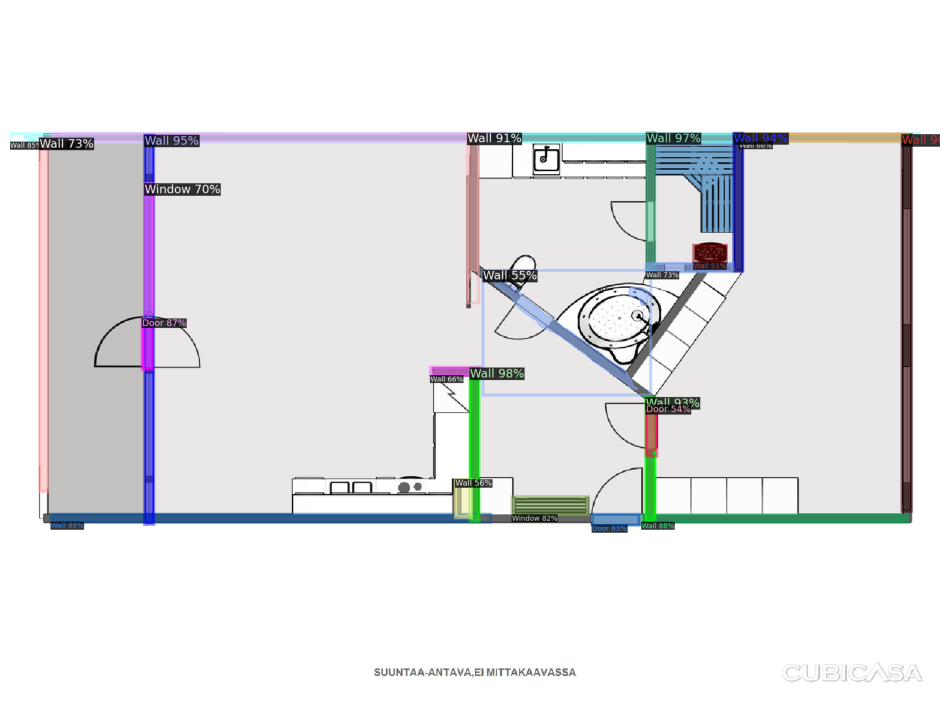

In [15]:
import cv2
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog
from detectron2 import model_zoo # Import model_zoo

# --- Load config and trained weights ---
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # Changed from 5 to 4 to match the trained model's class count
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/floorplan_detection_output/model_final.pth"  # path to your trained checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # confidence threshold
cfg.DATASETS.TEST = ("floorplan_test",)

cfg.MODEL.DEVICE = 'cpu'

predictor = DefaultPredictor(cfg)

# --- Run inference on one image ---
image_path = "/content/cubicasa_dataset/cubicasa5k/colorful/10052/F1_scaled.png"
img = cv2.imread(image_path)

outputs = predictor(img)  # predictions

# --- Visualize results in Colab ---
v = Visualizer(img[:, :, ::-1], MetadataCatalog.get("floorplan_train"), scale=1.2)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

plt.figure(figsize=(12, 12))
plt.imshow(out.get_image()[:, :, ::-1])
plt.axis("off")
plt.show()

# Batch Inference on Validation set

[01/17 10:47:47 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /content/drive/MyDrive/floorplan_detection_output/model_final.pth ...
[01/17 10:47:48 d2.data.datasets.coco]: Loaded 400 images in COCO format from /content/cubicasa_dataset/cubicasa5k/annotations/val.json
WARNING [01/17 10:47:48 d2.data.datasets.coco]: Filtered out 3 instances without valid segmentation. There might be issues in your dataset generation process.  Please check https://detectron2.readthedocs.io/en/latest/tutorials/datasets.html carefully


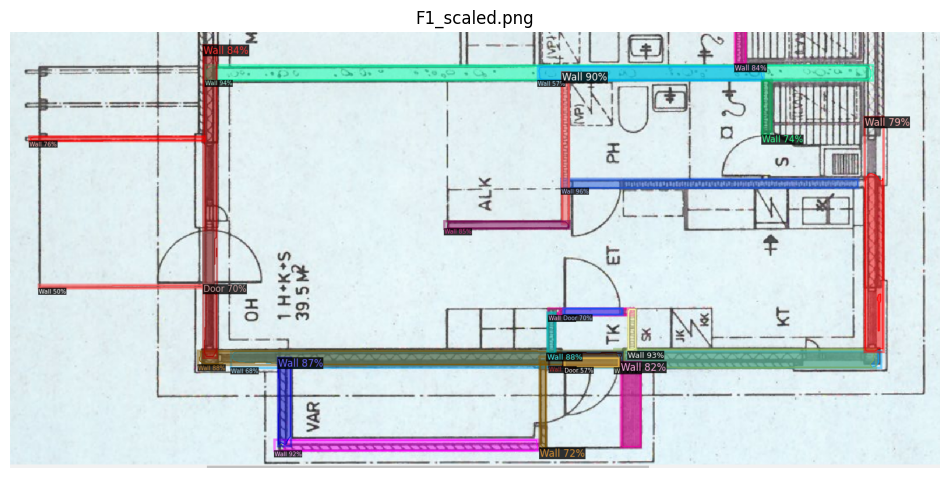

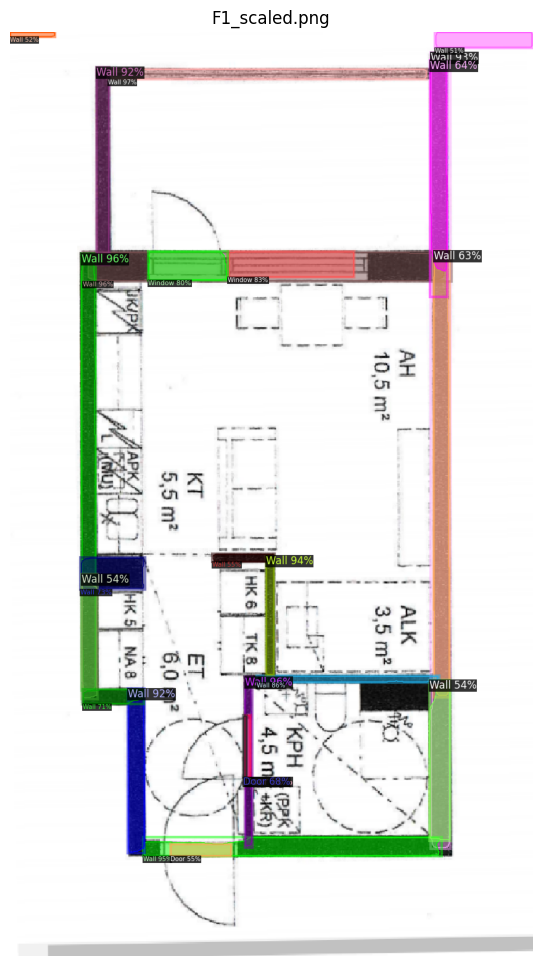

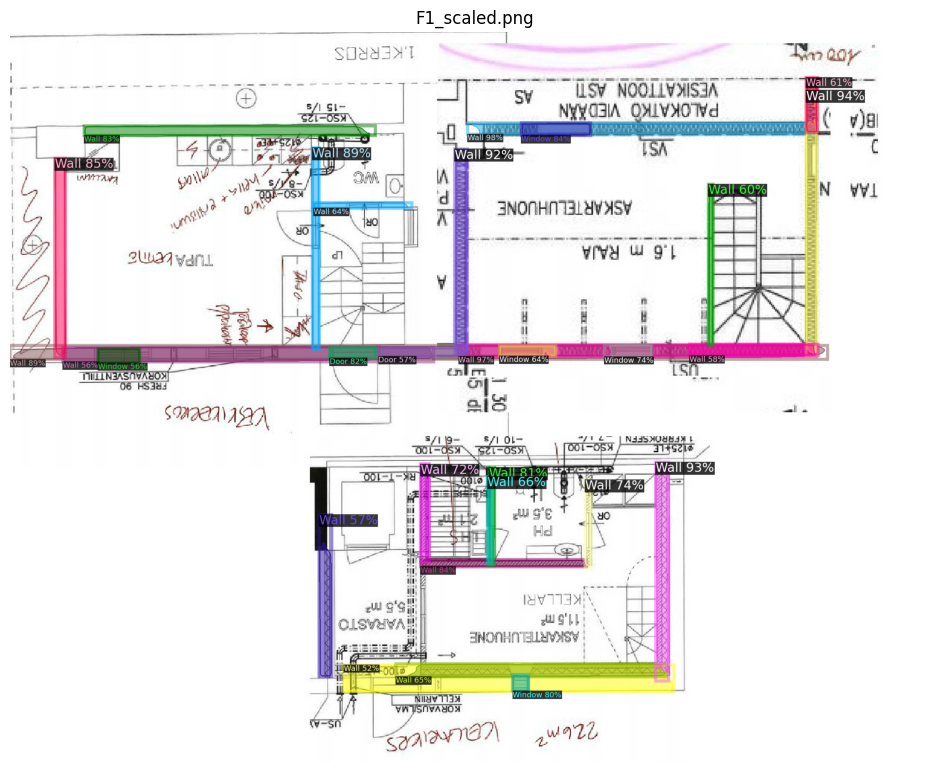

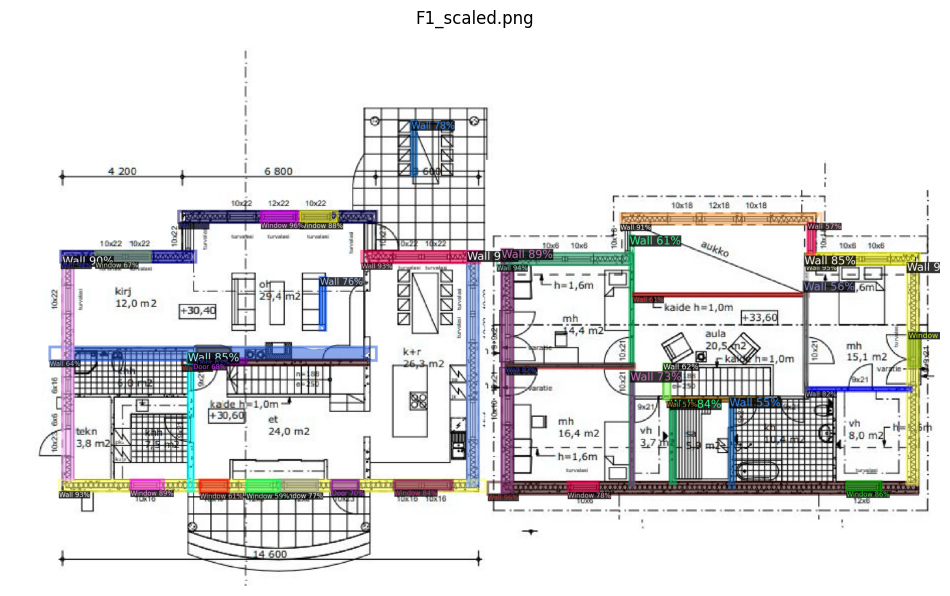

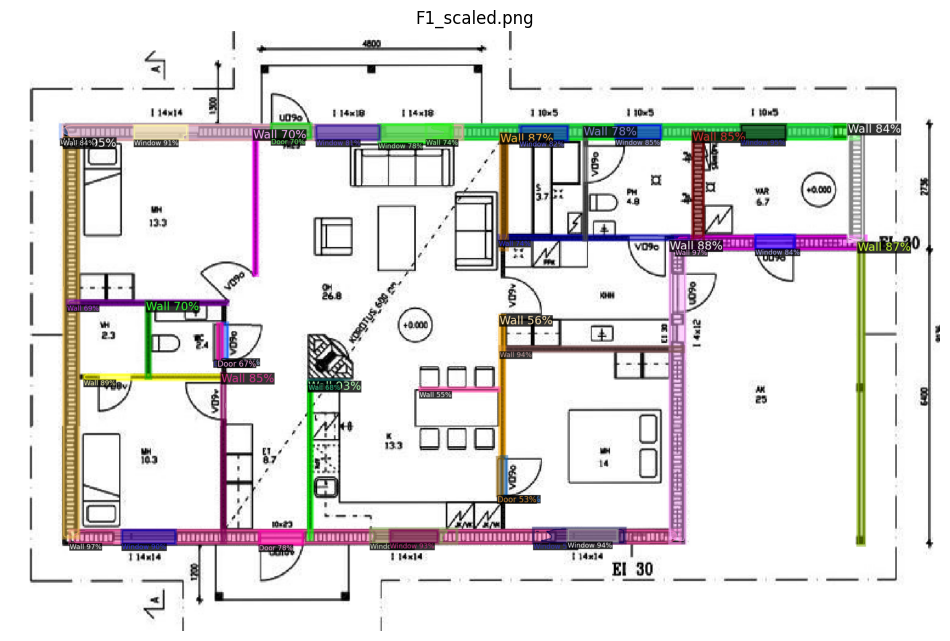

Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Processed and saved: /content/inference_val_results/F1_scaled_pred.png
Proces

In [16]:
import os, cv2
import matplotlib.pyplot as plt
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2 import model_zoo

# --- Load config and trained weights ---
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # Changed to 4 to match the trained model's class count
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/floorplan_detection_output/model_final.pth"  # Updated path to your trained checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5
cfg.DATASETS.TEST = ("floorplan_val",)

# Configure to use CPU
cfg.MODEL.DEVICE = 'cpu'

predictor = DefaultPredictor(cfg)

# --- Get validation dataset ---
dataset_dicts = DatasetCatalog.get("floorplan_val")
metadata = MetadataCatalog.get("floorplan_train")

# --- Output directory ---
output_dir = "/content/inference_val_results"
os.makedirs(output_dir, exist_ok=True)

# --- Run inference on all validation images ---
for i, d in enumerate(dataset_dicts):
    img_path = d["file_name"]
    img = cv2.imread(img_path)

    # Handle cases where image might not be loaded correctly
    if img is None:
        print(f"Warning: Could not load image from {img_path}. Skipping.")
        continue

    outputs = predictor(img)

    # Visualize predictions
    v = Visualizer(img[:, :, ::-1], metadata, scale=1.2)
    out = v.draw_instance_predictions(outputs["instances"].to("cpu"))

    # Save result
    # Ensure unique filenames for saving
    base_name = os.path.basename(img_path)
    file_name_without_ext, file_ext = os.path.splitext(base_name)
    save_path = os.path.join(output_dir, f"{file_name_without_ext}_pred{file_ext}")
    cv2.imwrite(save_path, out.get_image()[:, :, ::-1])

    # Optionally show inline in Colab, limit to first few images to avoid excessive output
    if i < 5: # Show only first 5 images for brevity
        plt.figure(figsize=(12, 12))
        plt.imshow(out.get_image()[:, :, ::-1])
        plt.axis("off")
        plt.title(os.path.basename(img_path))
        plt.show()
    else:
        print(f"Processed and saved: {save_path}")

print(f"Inference complete. Results saved to {output_dir}")

# **Evaluation**

In [1]:
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2 import model_zoo
import os

# --- Load config and trained weights --- (Re-initialize cfg)
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-InstanceSegmentation/mask_rcnn_R_50_FPN_3x.yaml"))

cfg.MODEL.ROI_HEADS.NUM_CLASSES = 4  # Match the number of classes your model was trained on
cfg.MODEL.WEIGHTS = "/content/drive/MyDrive/floorplan_detection_output/model_final.pth"  # Path to your trained checkpoint
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5   # Confidence threshold for evaluation
cfg.DATASETS.TEST = ("floorplan_val",) # Specify the validation dataset for evaluation

cfg.MODEL.DEVICE = 'cpu' # Ensure consistency with training and inference

# Create a predictor to load the model
predictor = DefaultPredictor(cfg)

# --- Create evaluator for your dataset ---
evaluator = COCOEvaluator("floorplan_val", cfg, False, output_dir="./output/")

# --- Build test loader ---
val_loader = build_detection_test_loader(cfg, "floorplan_val")

# --- Run evaluation ---
results = inference_on_dataset(predictor.model, val_loader, evaluator)
print(results)

KeyError: "Dataset 'floorplan_val' is not registered! Available datasets are: coco_2014_train, coco_2014_val, coco_2014_minival, coco_2014_valminusminival, coco_2017_train, coco_2017_val, coco_2017_test, coco_2017_test-dev, coco_2017_val_100, keypoints_coco_2014_train, keypoints_coco_2014_val, keypoints_coco_2014_minival, keypoints_coco_2014_valminusminival, keypoints_coco_2017_train, keypoints_coco_2017_val, keypoints_coco_2017_val_100, coco_2017_train_panoptic_separated, coco_2017_train_panoptic_stuffonly, coco_2017_train_panoptic, coco_2017_val_panoptic_separated, coco_2017_val_panoptic_stuffonly, coco_2017_val_panoptic, coco_2017_val_100_panoptic_separated, coco_2017_val_100_panoptic_stuffonly, coco_2017_val_100_panoptic, lvis_v1_train, lvis_v1_val, lvis_v1_test_dev, lvis_v1_test_challenge, lvis_v0.5_train, lvis_v0.5_val, lvis_v0.5_val_rand_100, lvis_v0.5_test, lvis_v0.5_train_cocofied, lvis_v0.5_val_cocofied, cityscapes_fine_instance_seg_train, cityscapes_fine_sem_seg_train, citys